🔹 Training Decoder Line D0 ...
🔹 Training Decoder Line D1 ...
🔹 Training Decoder Line D2 ...
🔹 Training Decoder Line D3 ...
🔹 Training Decoder Line D4 ...
🔹 Training Decoder Line D5 ...
🔹 Training Decoder Line D6 ...
🔹 Training Decoder Line D7 ...

=== 3→8 DECODER (MLP) ===
Overall Decoder Accuracy: 1.000

--- Output D0 ---
Accuracy: 1.0
Confusion Matrix:
 [[7 0]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         1

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

--- Output D1 ---
Accuracy: 1.0
Confusion Matrix:
 [[7 0]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         1

    accuracy         

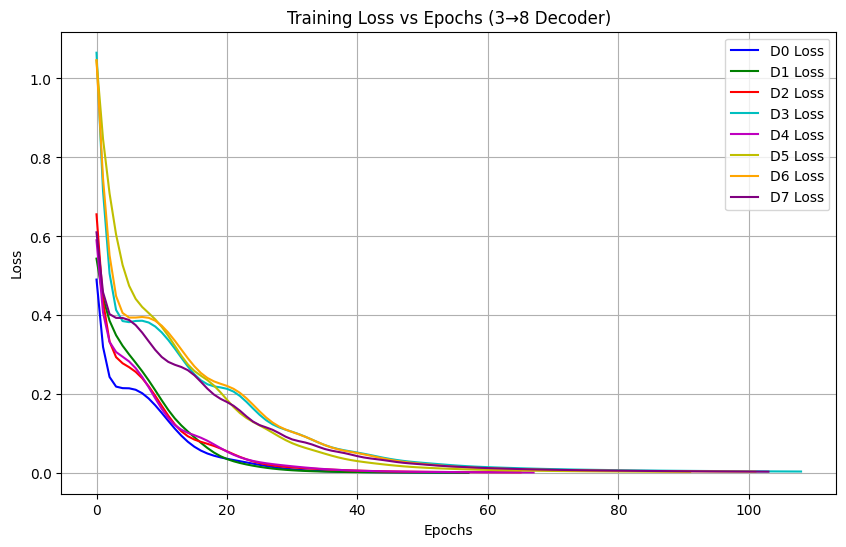

In [1]:
# decoder_3to8_mlp.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import os

# ======================================================
# 1️⃣ Define Dataset
# ======================================================
X = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])

# Outputs: 8 one-hot vectors (D0–D7)
y = np.eye(8, dtype=int)

# ======================================================
# 2️⃣ Train 8 MLP models (one per decoder line)
# ======================================================
models = []
preds = []
loss_curves = []
save_dir = "frontend/models"
os.makedirs(save_dir, exist_ok=True)

for i in range(8):
    print(f"🔹 Training Decoder Line D{i} ...")
    model = MLPClassifier(hidden_layer_sizes=(12,), activation='tanh',
                          solver='adam', learning_rate_init=0.05,
                          max_iter=2000, random_state=42 + i)
    model.fit(X, y[:, i])
    models.append(model)
    preds.append(model.predict(X))
    loss_curves.append(model.loss_curve_)

# Combine predictions
preds = np.column_stack(preds)

# ======================================================
# 3️⃣ Evaluate Performance
# ======================================================
accuracy = np.mean(np.all(preds == y, axis=1))
print("\n=== 3→8 DECODER (MLP) ===")
print(f"Overall Decoder Accuracy: {accuracy:.3f}\n")

for i in range(8):
    print(f"--- Output D{i} ---")
    print("Accuracy:", accuracy_score(y[:, i], preds[:, i]))
    print("Confusion Matrix:\n", confusion_matrix(y[:, i], preds[:, i]))
    print("Classification Report:\n", classification_report(y[:, i], preds[:, i]))

# ======================================================
# 4️⃣ Plot Loss Curves
# ======================================================
plt.figure(figsize=(10, 6))
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'orange', 'purple']
for i in range(8):
    plt.plot(loss_curves[i], color=colors[i % len(colors)], label=f'D{i} Loss')
plt.title("Training Loss vs Epochs (3→8 Decoder)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
import joblib
import os

save_dir = "frontend/models"
os.makedirs(save_dir, exist_ok=True)

# Suppose you have 8 trained models stored in a list called `models`
for i, model in enumerate(models):
    filename = os.path.join(save_dir, f"3to8_Decoder_D{i}_mlp.pkl")
    joblib.dump(model, filename)
    print(f"✅ Saved: {filename}")

✅ Saved: frontend/models/3to8_Decoder_D0_mlp.pkl
✅ Saved: frontend/models/3to8_Decoder_D1_mlp.pkl
✅ Saved: frontend/models/3to8_Decoder_D2_mlp.pkl
✅ Saved: frontend/models/3to8_Decoder_D3_mlp.pkl
✅ Saved: frontend/models/3to8_Decoder_D4_mlp.pkl
✅ Saved: frontend/models/3to8_Decoder_D5_mlp.pkl
✅ Saved: frontend/models/3to8_Decoder_D6_mlp.pkl
✅ Saved: frontend/models/3to8_Decoder_D7_mlp.pkl
